# Notebook 04 — Beat Overlay Analysis

Plots every individual heartbeat overlaid (no averaging) to expose beat-to-beat
variation in R height and R position. First step before registration.
All pipeline functions are copied verbatim from Notebook 02 — nothing modified.

**Window note:** `PRE_R_MS=100`, `POST_R_MS=150` (250 ms total) reuse the NB02
constants. At mouse HR ~400-500 bpm (RR ~120-150 ms) this window deliberately
overlaps the neighbouring beat. That overlap is **expected and diagnostic** — the
trailing deflection on the right of each overlay IS the next heartbeat.

In [1]:
# ── Configuration (change these) ──────────────────────────────────────────────
ANIMALS = [201, 146, 106, 111, 115, 117]   # clean first, then problem cases
CLEAN_IDS = {201, 146, 106}

# Beat window: reuse NB02 constants exactly — do NOT change
# At mouse HR ~400-500 bpm (RR ~120-150 ms) the 250 ms window overlaps the
# adjacent beat. Expected and diagnostic, not a bug.
PRE_R_MS         = 100   # ms before R  (NB02: PRE_R_MS)
POST_R_MS        = 150   # ms after  R  (NB02: POST_R_MS)
BEATS_TO_AVERAGE = 4     # for average_beats() signature; unused in overlay

# ── Imports ───────────────────────────────────────────────────────────────────
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch

# ── Project root (same auto-discovery as NB01/NB02) ───────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR    = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Data folder  : {DATA_DIR}')
print(f'Animals      : {ANIMALS}')
print(f'Beat window  : -{PRE_R_MS} ms to +{POST_R_MS} ms  ({PRE_R_MS+POST_R_MS} ms total)')
print('Note: window overlaps adjacent beat at mouse HR — expected.')

Project root : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project
Data folder  : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\data
Animals      : [201, 146, 106, 111, 115, 117]
Beat window  : -100 ms to +150 ms  (250 ms total)
Note: window overlaps adjacent beat at mouse HR — expected.


In [2]:
# ── Pipeline constants (NB02, verbatim) ───────────────────────────────────────
FS_DEFAULT       = 1000
BANDPASS_LOW_HZ  = 0.5
BANDPASS_HIGH_HZ = 150.0
BANDPASS_ORDER   = 2
REFRACTORY_MS    = 55
HR_ACCEPT_LOW    = 300
HR_ACCEPT_HIGH   = 700
GAP_MIN_S        = 10
GAP_MAX_S        = 120
GAP_MAX_LONG_S   = 900
LONG_USE_S       = 60
SINGLE_FALLBACK_S = 30
EXCLUDE_KEYWORDS = ('oc 1', 'oc 2', 'oc1', 'oc2', 'jugular', 'jugcan', 'injection', 'inject')
END_KEYWORDS     = ('end', 'done', 'stop')
START_HINTS      = ('baseline', 'ecg', 'start')

# ── Marker helpers (NB02, verbatim) ───────────────────────────────────────────
_MARKER_RE = re.compile(r'#([*1-3])')

def _looks_like_end(text):
    low = text.lower()
    return any(k in low for k in END_KEYWORDS)

def _looks_like_excluded(text):
    low = text.lower()
    return any(k in low for k in EXCLUDE_KEYWORDS)

def _looks_like_baseline(text):
    return 'baseline' in text.lower().replace('basline', 'baseline')

# ── parse_header_and_layout (NB02, verbatim) ──────────────────────────────────
def parse_header_and_layout(path):
    info = {}
    n_header = 0
    first_data_row = None
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if not s or s[0].isdigit() or s[0] in '+-.':
                first_data_row = line.rstrip('\n')
                break
            n_header += 1
            if '=' in line:
                key, _, rest = line.partition('=')
                info[key.strip()] = rest.strip('\n').strip('\t').split('\t')
    titles = [t.strip() for t in info.get('ChannelTitle', []) if t.strip()]
    n_channels = max(len(titles), 1)
    n_cols_first = len(first_data_row.split('\t')) if first_data_row else (n_channels + 1)
    lead_cols = max(1, n_cols_first - n_channels)
    ch3_idx = next((i for i, t in enumerate(titles) if t.lower() == 'channel 3'), 0)
    ecg_col = lead_cols + ch3_idx
    return n_header, lead_cols, ecg_col, titles

# ── load_ecg_file (NB02, verbatim) ────────────────────────────────────────────
def load_ecg_file(path, n_header, ecg_col):
    voltages, markers = [], []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(n_header):
            f.readline()
        for line in f:
            stripped = line.rstrip('\n')
            parts = stripped.split('\t')
            if len(parts) <= ecg_col:
                continue
            try:
                v = float(parts[ecg_col])
            except ValueError:
                v = np.nan
            voltages.append(v)
            m = _MARKER_RE.search(stripped)
            if m:
                markers.append((len(voltages) - 1, stripped[m.start():].strip(), m.group(1)))
    voltage = np.asarray(voltages, dtype=float)
    if np.isnan(voltage).any():
        idx = np.arange(len(voltage))
        good = ~np.isnan(voltage)
        if good.any():
            voltage = np.interp(idx, idx[good], voltage[good])
    return voltage, markers

# ── find_baseline_window (NB02, verbatim) ─────────────────────────────────────
def find_baseline_window(markers, n_samples, fs=FS_DEFAULT):
    MIN_GAP  = GAP_MIN_S      * fs
    MAX_GAP  = GAP_MAX_S      * fs
    LONG_GAP = GAP_MAX_LONG_S * fs
    LONG_USE = LONG_USE_S     * fs
    FALLBACK = SINGLE_FALLBACK_S * fs
    tagged = []
    for idx, text, prefix in markers:
        if _looks_like_excluded(text):
            continue
        tagged.append({'idx': idx, 'text': text, 'prefix': prefix, 'end': _looks_like_end(text)})
    starts = [m for m in tagged if not m['end']]
    ends   = [m for m in tagged if m['end']]
    def _try(_starts, _ends, lo, hi, label):
        for s in _starts:
            for e in _ends:
                if e['idx'] <= s['idx']:
                    continue
                gap = e['idx'] - s['idx']
                if lo <= gap <= hi:
                    return s, e, label
        return None
    for pre in ('*', '1', '2', '3'):
        result = _try([m for m in starts if m['prefix'] == pre],
                      [m for m in ends   if m['prefix'] == pre],
                      MIN_GAP, MAX_GAP, f'A_same_{pre}')
        if result:
            s, e, label = result
            return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    result = _try(starts, ends, MIN_GAP, MAX_GAP, 'B_cross')
    if result:
        s, e, label = result
        return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    bl_starts = [m for m in starts if _looks_like_baseline(m['text'])]
    bl_ends   = [m for m in ends   if _looks_like_baseline(m['text'])]
    result = _try(bl_starts, bl_ends, MIN_GAP, LONG_GAP, 'C_long_baseline')
    if result:
        s, e, label = result
        return s['idx'], min(s['idx'] + LONG_USE, e['idx'], n_samples), label, s['text'], e['text']
    candidate = next((m for m in starts if any(k in m['text'].lower() for k in START_HINTS)), None)
    if candidate is None and starts:
        candidate = starts[0]
    if candidate is None and tagged:
        candidate = tagged[0]
    if candidate is not None:
        return candidate['idx'], min(candidate['idx'] + FALLBACK, n_samples), 'D_single_30s', candidate['text'], None
    return None, None, 'no_markers', None, None

# ── bandpass_filter (NB02, verbatim) ──────────────────────────────────────────
def bandpass_filter(x, fs=FS_DEFAULT, low=BANDPASS_LOW_HZ, high=BANDPASS_HIGH_HZ, order=BANDPASS_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    y = filtfilt(b, a, x)
    for f0 in (50, 100, 150):
        bn, an = iirnotch(f0 / (fs / 2), Q=30)
        y = filtfilt(bn, an, y)
    return y

# ── _peaks_with_mad (NB02, verbatim) ──────────────────────────────────────────
def _peaks_with_mad(sig, fs=FS_DEFAULT, refractory_ms=REFRACTORY_MS):
    if sig.size == 0:
        return np.array([], dtype=int), np.nan, np.nan
    med = float(np.median(sig))
    mad = float(np.median(np.abs(sig - med)))
    if mad <= 0:
        return np.array([], dtype=int), med, mad
    height     = med + 4 * mad
    prominence = max(0.3 * mad, 0.005)
    distance   = int(refractory_ms * fs / 1000)
    peaks, _   = find_peaks(sig, height=height, distance=distance, prominence=prominence)
    return peaks, height, prominence

# ── detect_r_peaks (NB02, verbatim) ───────────────────────────────────────────
def detect_r_peaks(sig, fs=FS_DEFAULT):
    def _hr(peaks):
        if len(peaks) < 2:
            return np.nan
        return 60000.0 / np.mean(np.diff(peaks) * (1000.0 / fs))
    pos_peaks, pos_h, _ = _peaks_with_mad(sig, fs)
    pos_hr = _hr(pos_peaks)
    if HR_ACCEPT_LOW <= pos_hr <= HR_ACCEPT_HIGH if not np.isnan(pos_hr) else False:
        return pos_peaks, False, pos_hr, pos_h
    inv_peaks, inv_h, _ = _peaks_with_mad(-sig, fs)
    inv_hr = _hr(inv_peaks)
    if HR_ACCEPT_LOW <= inv_hr <= HR_ACCEPT_HIGH if not np.isnan(inv_hr) else False:
        return inv_peaks, True, inv_hr, inv_h
    def _dist(hr):
        if np.isnan(hr): return np.inf
        if hr < HR_ACCEPT_LOW: return HR_ACCEPT_LOW - hr
        if hr > HR_ACCEPT_HIGH: return hr - HR_ACCEPT_HIGH
        return 0.0
    if _dist(inv_hr) < _dist(pos_hr):
        return inv_peaks, True, inv_hr, inv_h
    return pos_peaks, False, pos_hr, pos_h

# ── average_beats (NB02, verbatim) ────────────────────────────────────────────
# Returns (template, t_ms, beats) where beats is the full (n_beats x win_len)
# matrix of individual aligned beats — used directly for the overlay.
def average_beats(sig, r_peaks, fs=FS_DEFAULT,
                  pre_ms=PRE_R_MS, post_ms=POST_R_MS,
                  group_size=BEATS_TO_AVERAGE):
    pre  = int(pre_ms  * fs / 1000)
    post = int(post_ms * fs / 1000)
    win_len = pre + post
    t_ms = (np.arange(win_len) - pre) * (1000.0 / fs)
    beats = [sig[r - pre: r + post] for r in r_peaks
             if r - pre >= 0 and r + post <= len(sig)]
    if not beats:
        return None, t_ms, None
    beats = np.vstack(beats)
    n_full_groups = len(beats) // group_size
    if n_full_groups == 0:
        return beats.mean(axis=0), t_ms, beats
    grouped = beats[:n_full_groups * group_size].reshape(n_full_groups, group_size, win_len)
    return grouped.mean(axis=1).mean(axis=0), t_ms, beats

print('NB02 helper functions loaded.')

NB02 helper functions loaded.


In [3]:
# ── New: confirm fs from LabChart header ──────────────────────────────────────
# LabChart header line: 'Interval=\t0.001 s' -> fs = 1000 Hz
# This is the definitive source of truth; FS_DEFAULT=1000 is only a fallback.
def read_fs_from_header(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if s and (s[0].isdigit() or s[0] in '+-'):
                break   # data section reached, no Interval line found
            if line.lower().startswith('interval'):
                m = re.search(r'([\d.]+(?:[eE][+-]?\d+)?)\s*s', line, re.IGNORECASE)
                if m:
                    interval_s = float(m.group(1))
                    if interval_s > 0:
                        return int(round(1.0 / interval_s))
    return None

# ── New: find data file for an animal by ID ───────────────────────────────────
def find_animal_file(animal_id, data_dir):
    for path in sorted(data_dir.glob('*.txt')):
        nums = re.findall(r'\d+', path.stem)
        if nums and int(nums[-1]) == animal_id:
            return path
    return None

print('Header-fs reader and file finder loaded.')

Header-fs reader and file finder loaded.



  ANIMAL 201  [CLEAN]
  File : 2024_12_14_201.txt
  fs   : 1000 Hz  (confirmed from Interval= header line)


  Window : 94.6s -> 119.6s  (25.0s)  [A_same_*]
  Beat window: 250 ms total; at RR~120-150 ms this overlaps the adjacent beat (expected).
  Peaks  : 208  HR=499.3 bpm  median RR=121.0 ms
  Beats  : 205 kept   3 dropped at edges
  -- Variation metrics (filtered beats) --
     R amplitude : mean=0.3951 mV  SD=0.0493 mV  CV=0.125
     R position  : SD=0.000 ms  (clean)
     SD envelope : mean=0.0262 mV  peak=0.1047 mV at t=123.0 ms


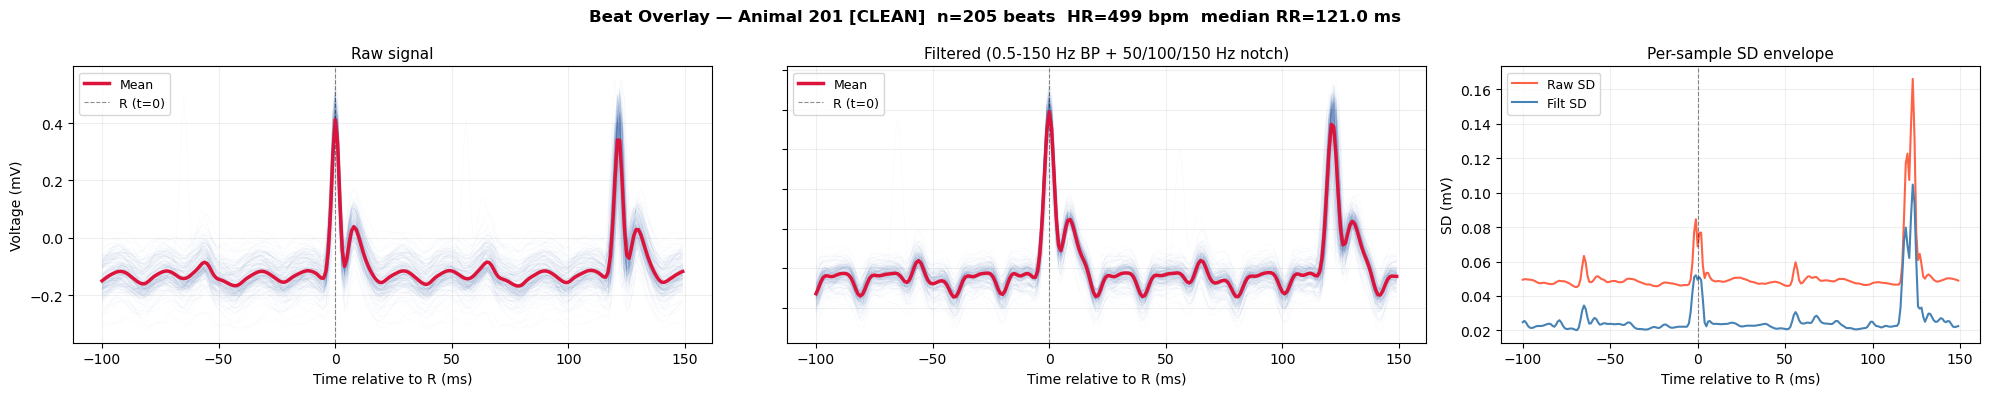

  Figure: 04_beat_overlay_201.png

  ANIMAL 146  [CLEAN]
  File : 2024_11_19_146.txt
  fs   : 1000 Hz  (confirmed from Interval= header line)


  Window : 69.5s -> 91.0s  (21.4s)  [A_same_*]
  Beat window: 250 ms total; at RR~120-150 ms this overlaps the adjacent beat (expected).
  Peaks  : 145  HR=405.7 bpm  median RR=151.0 ms
  Beats  : 143 kept   2 dropped at edges
  -- Variation metrics (filtered beats) --
     R amplitude : mean=0.5084 mV  SD=0.0699 mV  CV=0.137
     R position  : SD=1.254 ms  *** ALIGNMENT WARNING: SD > 1 ms ***
     SD envelope : mean=0.0300 mV  peak=0.1749 mV at t=149.0 ms


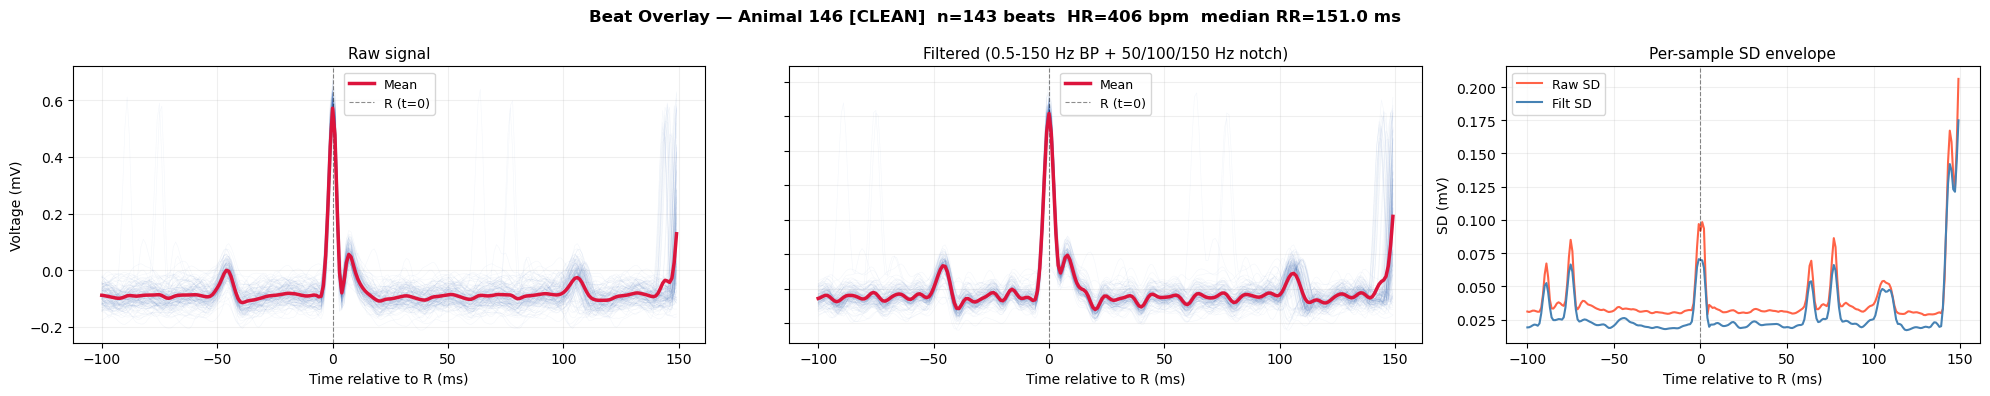

  Figure: 04_beat_overlay_146.png

  ANIMAL 106  [CLEAN]
  File : 2024_11_01_106.txt
  fs   : 1000 Hz  (confirmed from Interval= header line)


  Window : 25.0s -> 55.0s  (30.0s)  [D_single_30s]
  Beat window: 250 ms total; at RR~120-150 ms this overlaps the adjacent beat (expected).
  Peaks  : 232  HR=464.9 bpm  median RR=138.0 ms
  Beats  : 230 kept   2 dropped at edges
  -- Variation metrics (filtered beats) --
     R amplitude : mean=0.8481 mV  SD=0.3883 mV  CV=0.458
     R position  : SD=0.000 ms  (clean)
     SD envelope : mean=0.4088 mV  peak=0.7086 mV at t=-90.0 ms


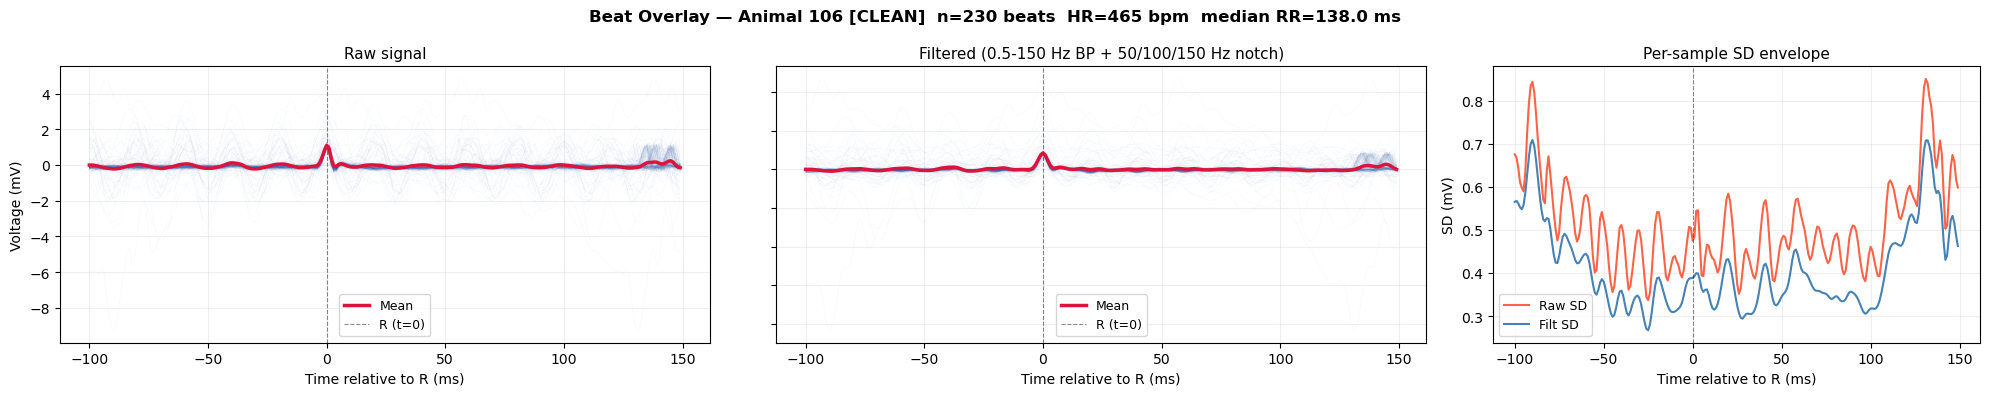

  Figure: 04_beat_overlay_106.png

  ANIMAL 111  [PROBLEM]
  File : 2024_11_13_111.txt
  fs   : 1000 Hz  (confirmed from Interval= header line)


  Window : 266.3s -> 281.4s  (15.1s)  [A_same_*]
  Beat window: 250 ms total; at RR~120-150 ms this overlaps the adjacent beat (expected).
  Peaks  : 72  HR=283.6 bpm  median RR=80.0 ms
  NOTE: HR=283.6 bpm outside 300-700 bpm — beats still extracted
  Beats  : 68 kept   4 dropped at edges
  -- Variation metrics (filtered beats) --
     R amplitude : mean=1.2645 mV  SD=0.2513 mV  CV=0.199
     R position  : SD=2.470 ms  *** ALIGNMENT WARNING: SD > 1 ms ***
     SD envelope : mean=0.4827 mV  peak=1.1403 mV at t=-100.0 ms


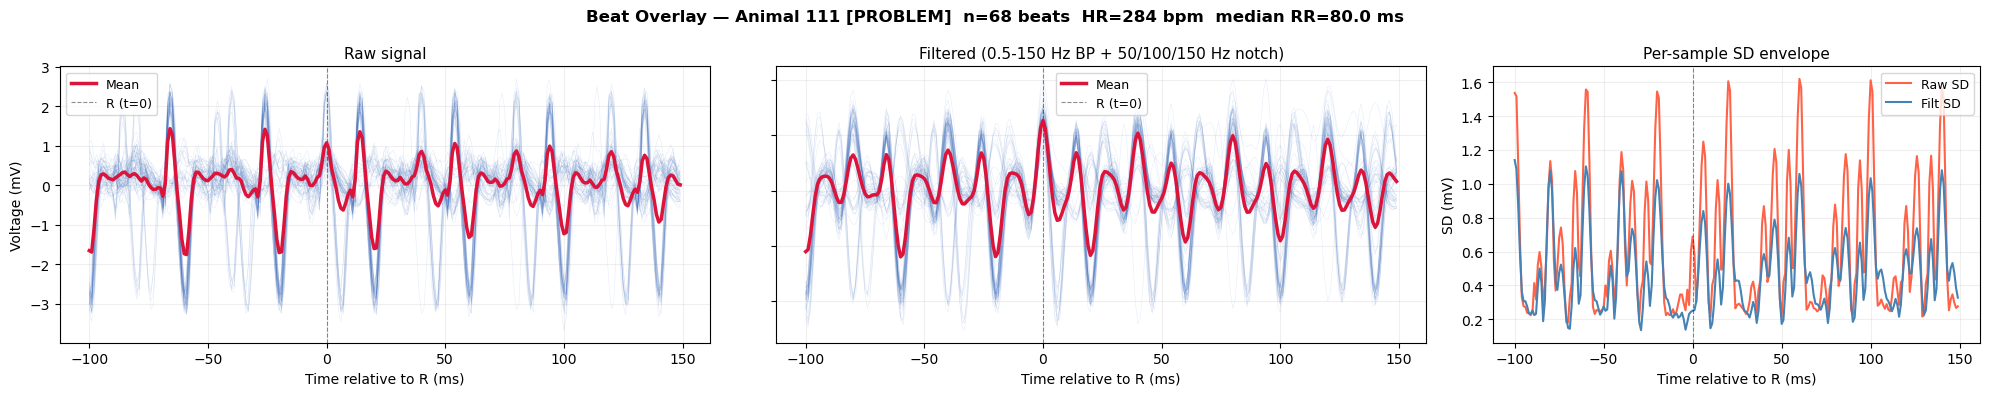

  Figure: 04_beat_overlay_111.png

  ANIMAL 115  [PROBLEM]
  File : 2024_11_13_115.txt
  fs   : 1000 Hz  (confirmed from Interval= header line)


  Window : 66.8s -> 121.0s  (54.2s)  [A_same_*]
  Beat window: 250 ms total; at RR~120-150 ms this overlaps the adjacent beat (expected).
  Peaks  : 408  HR=454.9 bpm  median RR=80.0 ms
  Beats  : 406 kept   2 dropped at edges
  -- Variation metrics (filtered beats) --
     R amplitude : mean=1.7059 mV  SD=0.4034 mV  CV=0.236
     R position  : SD=0.744 ms  (clean)
     SD envelope : mean=0.5107 mV  peak=1.2016 mV at t=80.0 ms


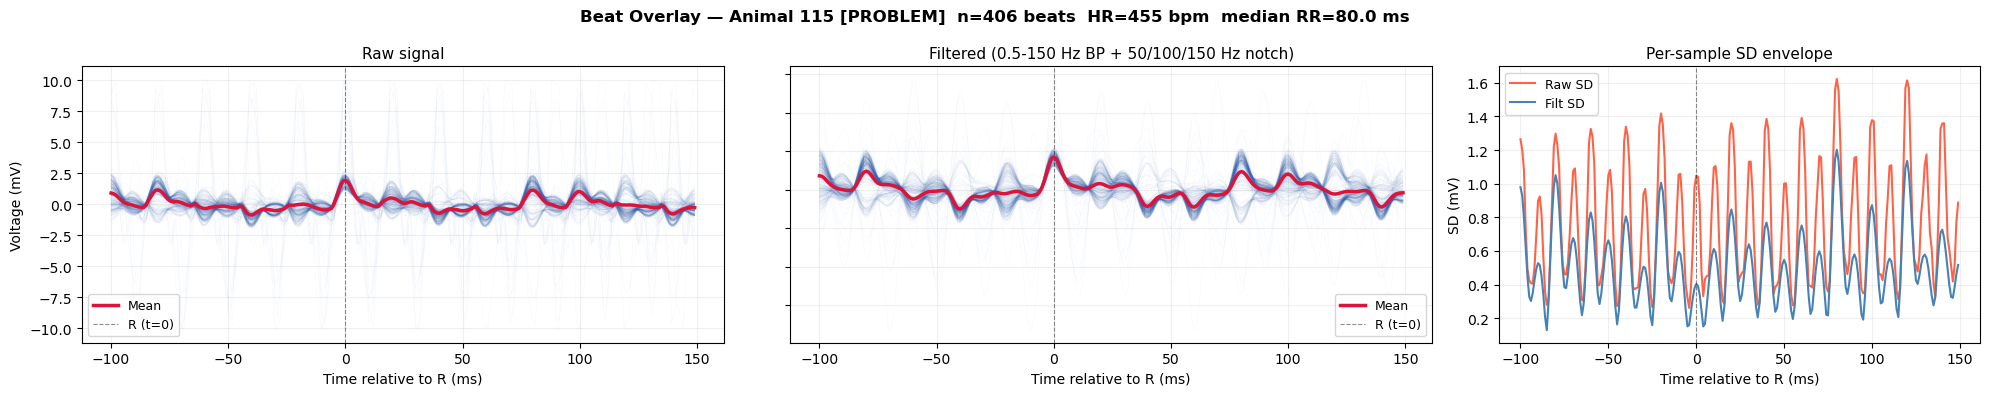

  Figure: 04_beat_overlay_115.png

  ANIMAL 117  [PROBLEM]
  File : 2024_11_14_117.txt
  fs   : 1000 Hz  (confirmed from Interval= header line)


  Window : 36.3s -> 56.7s  (20.4s)  [B_cross]
  Beat window: 250 ms total; at RR~120-150 ms this overlaps the adjacent beat (expected).
  Peaks  : 114  HR=336.2 bpm  median RR=122.0 ms
  Beats  : 112 kept   2 dropped at edges
  -- Variation metrics (filtered beats) --
     R amplitude : mean=0.7962 mV  SD=0.8585 mV  CV=1.078
     R position  : SD=2.303 ms  *** ALIGNMENT WARNING: SD > 1 ms ***
     SD envelope : mean=0.5118 mV  peak=0.9638 mV at t=-53.0 ms


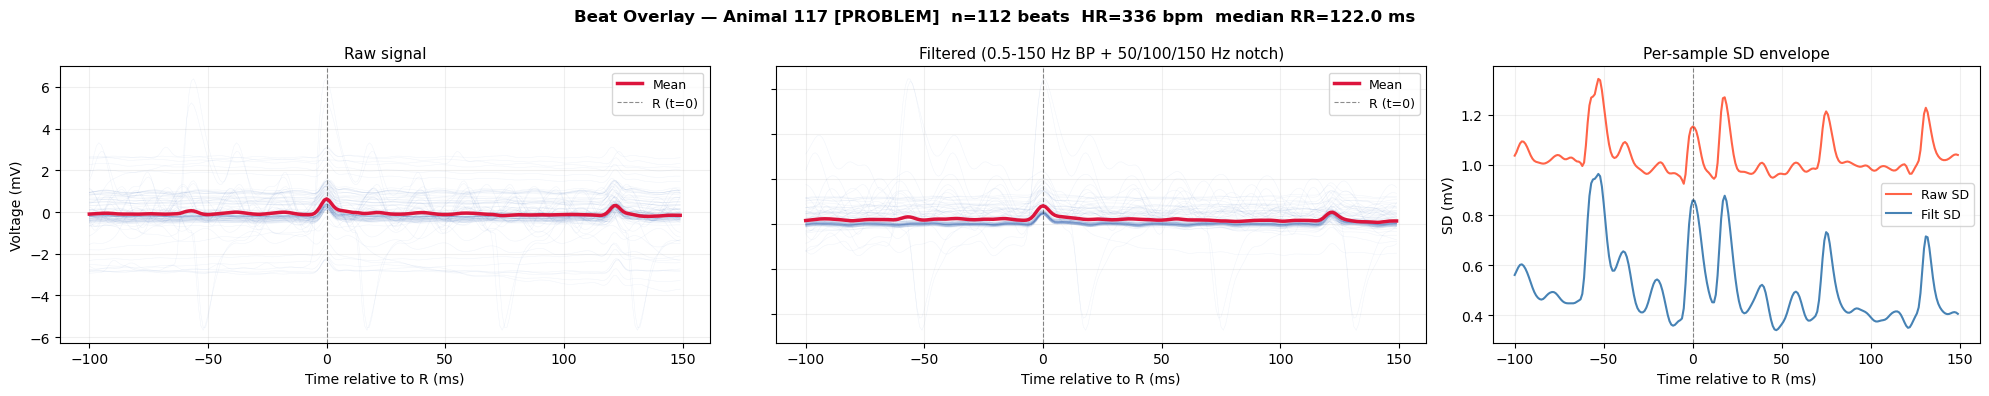

  Figure: 04_beat_overlay_117.png

  LOOP COMPLETE


In [4]:
summary_rows = []

for animal_id in ANIMALS:
    label = 'CLEAN' if animal_id in CLEAN_IDS else 'PROBLEM'
    print(f'\n{"="*72}')
    print(f'  ANIMAL {animal_id}  [{label}]')
    print(f'{"="*72}')

    # ── Locate file ───────────────────────────────────────────────────────────
    path = find_animal_file(animal_id, DATA_DIR)
    if path is None:
        print(f'  ERROR: no file found for animal {animal_id}')
        continue
    print(f'  File : {path.name}')

    # ── Confirm fs from header ────────────────────────────────────────────────
    fs = read_fs_from_header(path)
    if fs is None:
        print(f'  WARNING: Interval= not in header — using FS_DEFAULT={FS_DEFAULT} Hz')
        fs = FS_DEFAULT
    else:
        print(f'  fs   : {fs} Hz  (confirmed from Interval= header line)')

    # ── Load signal + find baseline window ────────────────────────────────────
    try:
        n_header, lead_cols, ecg_col, titles = parse_header_and_layout(path)
        voltage, markers = load_ecg_file(path, n_header, ecg_col)
    except Exception as exc:
        print(f'  ERROR loading file: {exc}')
        continue

    start, end, rule, s_text, e_text = find_baseline_window(markers, len(voltage), fs)
    if start is None:
        print(f'  ERROR: no baseline window found')
        continue

    seg_raw  = voltage[start:end].copy()
    dur_s    = len(seg_raw) / fs
    print(f'  Window : {start/fs:.1f}s -> {end/fs:.1f}s  ({dur_s:.1f}s)  [{rule}]')
    print(f'  Beat window: {PRE_R_MS+POST_R_MS} ms total; at RR~120-150 ms '
          f'this overlaps the adjacent beat (expected).')

    # ── Filter + detect R peaks ───────────────────────────────────────────────
    seg_filt = bandpass_filter(seg_raw, fs=fs)
    peaks, inverted, hr_bpm, _ = detect_r_peaks(seg_filt, fs=fs)
    if inverted:
        seg_raw  = -seg_raw
        seg_filt = -seg_filt
        print(f'  NOTE: polarity flipped (inverted signal detected)')
    if len(peaks) < 3:
        print(f'  ERROR: only {len(peaks)} peaks detected — skip')
        continue

    rr_ms     = np.diff(peaks) * 1000.0 / fs
    median_rr = float(np.median(rr_ms))
    print(f'  Peaks  : {len(peaks)}  HR={hr_bpm:.1f} bpm  median RR={median_rr:.1f} ms')
    if hr_bpm < HR_ACCEPT_LOW or hr_bpm > HR_ACCEPT_HIGH:
        print(f'  NOTE: HR={hr_bpm:.1f} bpm outside 300-700 bpm — beats still extracted')

    # ── Extract beats via average_beats() ────────────────────────────────────
    # average_beats() silently drops edge beats (window runs off recording end).
    # Count dropped explicitly so nothing is excluded without reporting.
    pre_samp  = int(PRE_R_MS  * fs / 1000)
    post_samp = int(POST_R_MS * fs / 1000)
    n_edge_dropped = sum(1 for r in peaks
                         if r - pre_samp < 0 or r + post_samp > len(seg_raw))

    _, t_ms, beats_raw  = average_beats(seg_raw,  peaks, fs=fs,
                                         pre_ms=PRE_R_MS, post_ms=POST_R_MS)
    _, t_ms, beats_filt = average_beats(seg_filt, peaks, fs=fs,
                                         pre_ms=PRE_R_MS, post_ms=POST_R_MS)

    if beats_raw is None or beats_filt is None:
        print(f'  ERROR: average_beats returned None')
        continue

    n_beats = len(beats_raw)
    print(f'  Beats  : {n_beats} kept   {n_edge_dropped} dropped at edges')
    if n_beats < 2:
        print(f'  ERROR: fewer than 2 beats — skip')
        continue

    # ── Variation metrics ─────────────────────────────────────────────────────
    # t_ms == 0 is where R should be (beats are cut exactly at the detected peak)
    r_idx = int(np.argmin(np.abs(t_ms)))

    # R amplitude (filtered, at alignment index)
    r_amps = beats_filt[:, r_idx]
    r_mean = float(np.mean(r_amps))
    r_sd   = float(np.std(r_amps, ddof=1))
    r_cv   = r_sd / abs(r_mean) if r_mean != 0 else np.nan

    # R position jitter: re-find local max in +/-15 ms around r_idx.
    # Should be ~0 sample offset because beats are cut ON the detected peak.
    # A non-zero SD here would mean the detector misfired on some beats.
    search_half = max(2, int(15 * fs / 1000))
    r_offsets_ms = []
    for b in beats_filt:
        lo = max(0, r_idx - search_half)
        hi = min(len(b), r_idx + search_half + 1)
        local_peak = lo + int(np.argmax(b[lo:hi]))
        r_offsets_ms.append((local_peak - r_idx) * 1000.0 / fs)
    r_pos_sd = float(np.std(r_offsets_ms, ddof=1))

    # Per-sample SD envelope (where in the beat does variation live?)
    sd_raw  = np.std(beats_raw,  axis=0, ddof=1)
    sd_filt = np.std(beats_filt, axis=0, ddof=1)
    peak_sd_t = float(t_ms[np.argmax(sd_filt)])

    print(f'  -- Variation metrics (filtered beats) --')
    print(f'     R amplitude : mean={r_mean:.4f} mV  SD={r_sd:.4f} mV  CV={r_cv:.3f}')
    r_pos_flag = '  *** ALIGNMENT WARNING: SD > 1 ms ***' if r_pos_sd > 1.0 else '  (clean)'
    print(f'     R position  : SD={r_pos_sd:.3f} ms{r_pos_flag}')
    print(f'     SD envelope : mean={np.mean(sd_filt):.4f} mV  '
          f'peak={np.max(sd_filt):.4f} mV at t={peak_sd_t:.1f} ms')

    # ── Overlay plot ──────────────────────────────────────────────────────────
    # alpha scales with n_beats so density is visible regardless of beat count
    alpha     = max(0.04, min(0.30, 8.0 / n_beats))
    mean_raw  = beats_raw.mean(axis=0)
    mean_filt = beats_filt.mean(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(20, 4),
                              gridspec_kw={'width_ratios': [2, 2, 1.5]})
    fig.suptitle(
        f'Beat Overlay — Animal {animal_id} [{label}]  '
        f'n={n_beats} beats  HR={hr_bpm:.0f} bpm  median RR={median_rr:.1f} ms',
        fontsize=12, fontweight='bold')

    ax_raw, ax_filt, ax_sd = axes

    # Left panel: raw
    for b in beats_raw:
        ax_raw.plot(t_ms, b, color='#3366BB', alpha=alpha, linewidth=0.4)
    ax_raw.plot(t_ms, mean_raw, color='crimson', linewidth=2.5, zorder=5, label='Mean')
    ax_raw.axvline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.45, label='R (t=0)')
    ax_raw.set_title('Raw signal', fontsize=11)
    ax_raw.set_xlabel('Time relative to R (ms)')
    ax_raw.set_ylabel('Voltage (mV)')
    ax_raw.legend(fontsize=9)
    ax_raw.grid(alpha=0.2)

    # Middle panel: filtered
    for b in beats_filt:
        ax_filt.plot(t_ms, b, color='#3366BB', alpha=alpha, linewidth=0.4)
    ax_filt.plot(t_ms, mean_filt, color='crimson', linewidth=2.5, zorder=5, label='Mean')
    ax_filt.axvline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.45, label='R (t=0)')
    ax_filt.set_title('Filtered (0.5-150 Hz BP + 50/100/150 Hz notch)', fontsize=11)
    ax_filt.set_xlabel('Time relative to R (ms)')
    ax_filt.legend(fontsize=9)
    ax_filt.grid(alpha=0.2)
    ax_filt.tick_params(labelleft=False)

    # Right panel: SD envelope
    ax_sd.plot(t_ms, sd_raw,  color='tomato',    linewidth=1.5, label='Raw SD')
    ax_sd.plot(t_ms, sd_filt, color='steelblue', linewidth=1.5, label='Filt SD')
    ax_sd.axvline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.45)
    ax_sd.set_title('Per-sample SD envelope', fontsize=11)
    ax_sd.set_xlabel('Time relative to R (ms)')
    ax_sd.set_ylabel('SD (mV)')
    ax_sd.legend(fontsize=9)
    ax_sd.grid(alpha=0.2)

    fig.tight_layout()
    fig_path = FIGURES_DIR / f'04_beat_overlay_{animal_id:03d}.png'
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Figure: {fig_path.name}')

    summary_rows.append({
        'animal':        animal_id,
        'group':         label,
        'fs_hz':         fs,
        'n_beats':       n_beats,
        'n_edge_dropped': n_edge_dropped,
        'median_rr_ms':  round(median_rr, 1),
        'r_amp_mean_mv': round(r_mean, 4),
        'r_amp_sd_mv':   round(r_sd,   4),
        'r_amp_cv':      round(r_cv,   3) if not np.isnan(r_cv) else None,
        'r_pos_sd_ms':   round(r_pos_sd, 3),
        'sd_env_mean_mv': round(float(np.mean(sd_filt)), 4),
        'sd_env_peak_mv': round(float(np.max(sd_filt)),  4),
        'sd_peak_t_ms':   round(peak_sd_t, 1),
    })

print(f'\n{"="*72}')
print('  LOOP COMPLETE')
print(f'{"="*72}')

In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
if summary_rows:
    sdf = pd.DataFrame(summary_rows)
    print('\n' + '='*72)
    print('SUMMARY TABLE')
    print('='*72)
    with pd.option_context('display.max_columns', 20, 'display.width', 130,
                           'display.float_format', '{:.3f}'.format):
        print(sdf.to_string(index=False))
    out_csv = OUTPUTS_DIR / 'beat_overlay_summary.csv'
    sdf.to_csv(out_csv, index=False)
    print(f'\nSaved: {out_csv}')
    print('\nKey: r_amp_sd_mv = beat-to-beat R amplitude variability (mV)')
    print('     r_pos_sd_ms  = R alignment jitter (should be ~0 if peaks cut ON R)')
    print('     sd_env_peak  = max per-sample SD in window (where variation is largest)')
else:
    print('No animals processed successfully.')


SUMMARY TABLE
 animal   group  fs_hz  n_beats  n_edge_dropped  median_rr_ms  r_amp_mean_mv  r_amp_sd_mv  r_amp_cv  r_pos_sd_ms  sd_env_mean_mv  sd_env_peak_mv  sd_peak_t_ms
    201   CLEAN   1000      205               3       121.000          0.395        0.049     0.125        0.000           0.026           0.105       123.000
    146   CLEAN   1000      143               2       151.000          0.508        0.070     0.137        1.254           0.030           0.175       149.000
    106   CLEAN   1000      230               2       138.000          0.848        0.388     0.458        0.000           0.409           0.709       -90.000
    111 PROBLEM   1000       68               4        80.000          1.264        0.251     0.199        2.470           0.483           1.140      -100.000
    115 PROBLEM   1000      406               2        80.000          1.706        0.403     0.236        0.744           0.511           1.202        80.000
    117 PROBLEM   1000      112

## Part 3 - Pipeline validation overlay (raw -> filtered -> features)

Supervisor's mandatory sanity check. For a **clean** and an **irregular** animal:
the raw unfiltered signal, the filtered signal with detected R-peaks, and the
averaged-beat template with the P/Q/R/S/J/T landmarks and the QT interval marked.
If the landmarks sit correctly, the extracted features can be trusted.


In [ ]:
# Uses the pipeline functions defined above (parse_header_and_layout,
# bandpass_filter, detect_r_peaks, average_beats) - nothing new imported.
ZOOM_S = 2.5  # seconds shown in the continuous-signal panels

def _win_time(template, t_ms, a, b, mode):
    m = (t_ms >= a) & (t_ms <= b)
    if not m.any():
        return None
    seg, tt = template[m], t_ms[m]
    return float(tt[np.argmax(seg) if mode == "max" else np.argmin(seg)])

def plot_overlay_validation(animal_id):
    path = find_animal_file(animal_id, DATA_DIR)
    if path is None:
        print(f"animal {animal_id}: file not found"); return
    n_header, lead, ecg_col, titles = parse_header_and_layout(path)
    voltage, markers = load_ecg_file(path, n_header, ecg_col)
    start, end, rule, s_t, e_t = find_baseline_window(markers, len(voltage))
    raw  = voltage[start:end]
    filt = bandpass_filter(raw)
    peaks, inverted, hr, _ = detect_r_peaks(filt)
    if inverted:
        filt = -filt
    rr_ms = np.diff(peaks) * (1000.0 / FS_DEFAULT)
    template, t_ms, beats = average_beats(filt, peaks)

    nz   = int(ZOOM_S * FS_DEFAULT)
    tsec = np.arange(min(nz, len(filt))) / FS_DEFAULT
    pk   = peaks[peaks < len(tsec)]

    fig, ax = plt.subplots(3, 1, figsize=(12, 10))
    ax[0].plot(tsec, raw[:len(tsec)], color="#888", lw=0.7)
    ax[0].set_title(f"1. RAW unfiltered  -  Animal {animal_id}  ({path.name})",
                    fontweight="bold"); ax[0].set_ylabel("mV")

    ax[1].plot(tsec, filt[:len(tsec)], color="#1f6f4a", lw=0.8)
    ax[1].plot(pk / FS_DEFAULT, filt[pk], "v", color="#c9432b", ms=8,
               label=f"detected R-peaks (HR {hr:.0f} bpm, {len(peaks)} beats)")
    ax[1].set_title("2. FILTERED (bandpass + notch) with detected R-peaks",
                    fontweight="bold")
    ax[1].set_ylabel("mV"); ax[1].set_xlabel("time (s)"); ax[1].legend(loc="upper right")

    base = float(np.median(template[t_ms < -70])) if (t_ms < -70).any() else 0.0
    ax[2].plot(t_ms, template, color="black", lw=1.6)
    ax[2].axhline(base, color="gray", ls=":", lw=1, alpha=0.7)
    landmarks = [(_win_time(template, t_ms, -70, -35, "max"), "P", "#8e44ad"),
                 (_win_time(template, t_ms, -14,  -2, "min"), "Q", "#2980b9"),
                 (0.0,                                        "R", "#c9432b"),
                 (_win_time(template, t_ms,   2,  18, "max"), "J", "#d35400"),
                 (_win_time(template, t_ms,   8,  32, "min"), "S", "#16a085"),
                 (_win_time(template, t_ms,  20,  90, "min"), "T", "#2c3e50")]
    for tm, lab, c in landmarks:
        if tm is None:
            continue
        idx = int(np.argmin(np.abs(t_ms - tm)))
        ax[2].plot(tm, template[idx], "o", color=c, ms=8, zorder=5)
        ax[2].annotate(lab, (tm, template[idx]), textcoords="offset points",
                       xytext=(0, 8), ha="center", fontweight="bold", color=c)
    # QT interval: Q-onset -> T-wave return toward baseline (RR-bounded, transparent)
    q_t = landmarks[1][0]; t_t = landmarks[5][0]
    if q_t is not None and t_t is not None:
        after = t_ms >= t_t
        ret = t_ms[after][np.where(template[after] >= base - 0.01)[0]]
        t_end = float(ret[0]) if len(ret) else t_t
        qt = t_end - q_t
        y = template.min() - 0.03
        ax[2].annotate("", xy=(t_end, y), xytext=(q_t, y),
                       arrowprops=dict(arrowstyle="<->", color="#c0392b", lw=1.5))
        ax[2].text((q_t + t_end) / 2, y - 0.02, f"QT {qt:.0f} ms", ha="center",
                   color="#c0392b", fontweight="bold")
    r_p2p = float(template.max() - template.min())
    ax[2].set_title("3. Averaged-beat TEMPLATE with extracted features overlaid",
                    fontweight="bold")
    ax[2].set_xlabel("time relative to R-peak (ms)"); ax[2].set_ylabel("mV")
    ax[2].set_xlim(-100, 110)
    ax[2].text(0.5, -0.30, f"HR {hr:.0f} bpm  |  {len(peaks)} beats  |  "
               f"R peak-to-peak {r_p2p:.2f} mV", transform=ax[2].transAxes,
               ha="center", bbox=dict(boxstyle="round", fc="#f4f4f4", ec="#ccc"))
    for a in ax:
        a.grid(alpha=0.2)
    fig.suptitle(f"Pipeline validation - Animal {animal_id}", fontweight="bold")
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])
    fig.savefig(FIGURES_DIR / f"overlay_validation_A{animal_id}.png", dpi=150)
    plt.show()

# Clean (regular) vs irregular (flagged) - the strongest before/after contrast
plot_overlay_validation(201)   # clean, rr_cv ~0.07
plot_overlay_validation(111)   # irregular, NEEDS_REVIEW, rr_cv ~1.5
